# Heart Disease Diagnosis: Data Preparation

This notebook follows the exact same structure as the diabetes project,
but this time the data is 100% real: the **UCI Cleveland Heart Disease
dataset**, 303 real patients examined at the Cleveland Clinic Foundation,
each with 13 real clinical measurements and a real diagnosis outcome.

This is one of the most widely used datasets in clinical machine learning
research, and it is freely and reliably downloadable, unlike a tabular
malaria dataset, which does not exist publicly (real public malaria data
is blood-smear images, a computer vision problem, not a table of symptoms).

**What this notebook covers:**
1. Download and load the real dataset
2. Inspect it
3. Explore it visually (EDA)
4. Check for missing or invalid values
5. Engineer a few clinically-informed features
6. Split into train / validation / test
7. Scale the features and save everything to disk (CSV, JSON, and PKL)


## Step 0: Get the dataset

Run this once, before starting:

```bash
wget https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv
```

This is a cleaned, standard copy of the UCI Cleveland Heart Disease dataset
(originally from Janosi, Steinbrunn, Pfisterer & Detrano, 1988, UCI Machine
Learning Repository). You should end up with `heart.csv` in the same
folder as this notebook.

## Step 1: Import libraries

In [3]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Step 2: Load and inspect

The same first questions as always: shape, duplicates, missing values,
what do the values actually look like.

In [4]:
df = pd.read_csv('heart.csv')

print(f"Shape:         {df.shape}")
print(f"Duplicates:    {df.duplicated().sum()}")
print(f"Missing (NaN): {df.isnull().sum().sum()}")

df.head()


Shape:         (303, 14)
Duplicates:    1
Missing (NaN): 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
df.describe().round(2)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


### What each column means

This dataset uses medical shorthand column names, worth writing down
before going further:

| Column | Meaning |
|---|---|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0-3, 0 = typical angina ... 3 = asymptomatic) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) |
| `restecg` | Resting ECG results (0-2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | Slope of the peak exercise ST segment (0-2) |
| `ca` | Number of major vessels colored by fluoroscopy (0-4) |
| `thal` | Thalassemia result (blood disorder test, 1-3) |
| `target` | 1 = heart disease present, 0 = absent (**this is what we predict**) |

### Class balance

No Disease: 138  (45.5%)
Disease:    165  (54.5%)


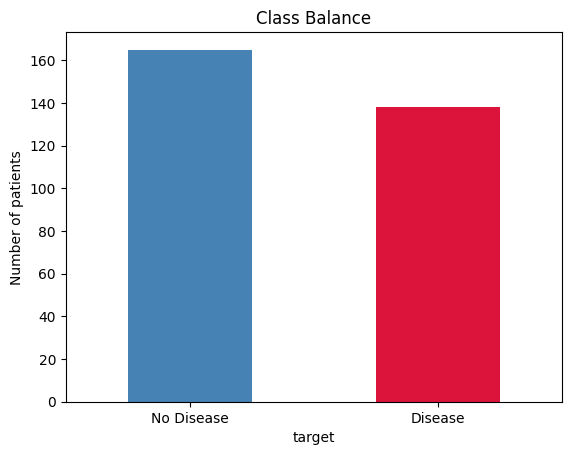

In [6]:
counts = df['target'].value_counts()

print(f"No Disease: {counts[0]}  ({counts[0] / len(df):.1%})")
print(f"Disease:    {counts[1]}  ({counts[1] / len(df):.1%})")

counts.plot(kind='bar', color=['steelblue', 'crimson'])
plt.xticks([0, 1], ['No Disease', 'Disease'], rotation=0)
plt.title('Class Balance')
plt.ylabel('Number of patients')
plt.show()


This dataset happens to be fairly balanced already, roughly 54% vs 46%,
which is a nice contrast with the diabetes dataset (65/35). Not every real
dataset is imbalanced, but you should always check, never assume.

## Step 3: Explore the data visually (EDA)

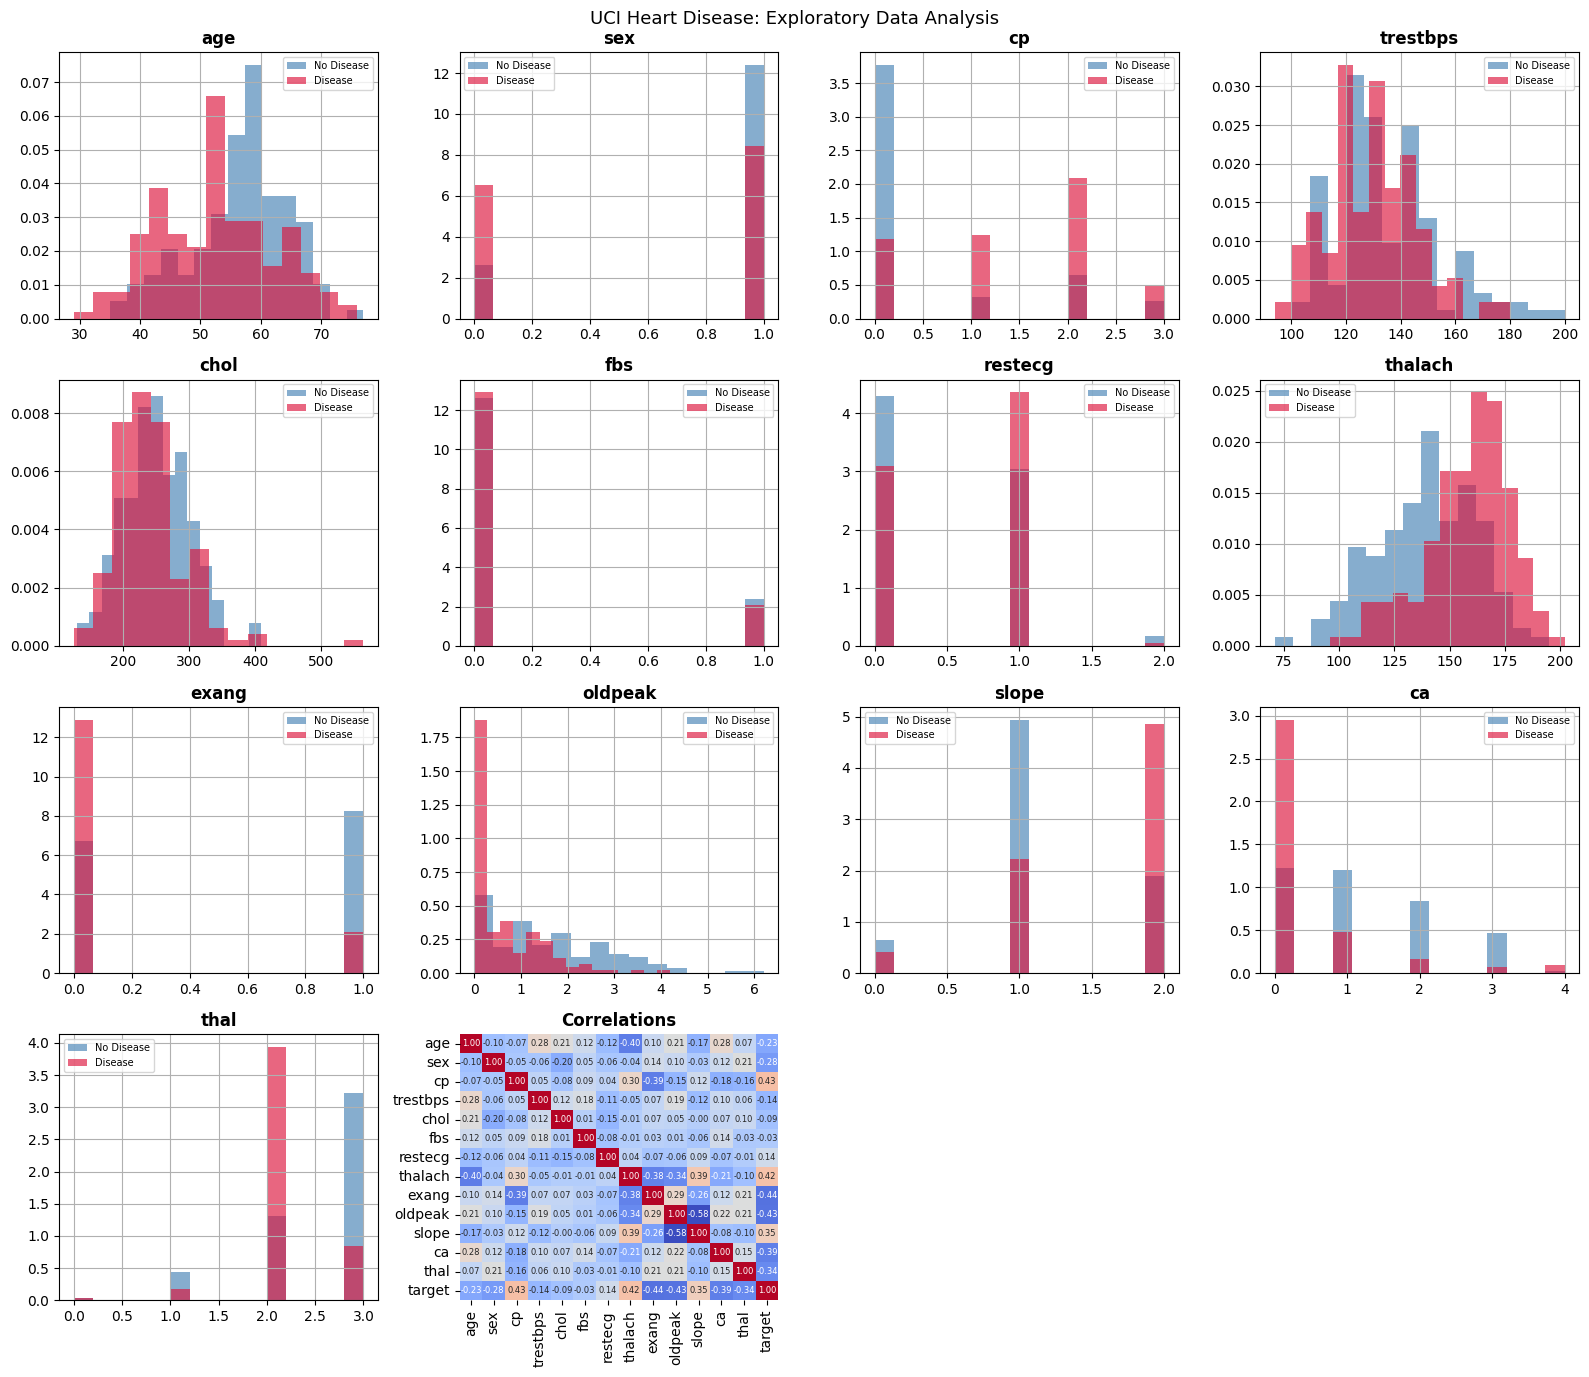

In [8]:
FEATURES = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
            'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    df[df['target'] == 0][col].hist(ax=axes[i], bins=15, alpha=0.65,
                                     color='steelblue', label='No Disease', density=True)
    df[df['target'] == 1][col].hist(ax=axes[i], bins=15, alpha=0.65,
                                     color='crimson', label='Disease', density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=7)

sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[13], cbar=False, annot_kws={'size': 6})
axes[13].set_title('Correlations', fontweight='bold')
axes[14].axis('off')
axes[15].axis('off')

plt.suptitle('UCI Heart Disease: Exploratory Data Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('heart_eda.png', dpi=150, bbox_inches='tight')
plt.show()


A few things worth pointing out to students in this real data: `thalach`
(max heart rate achieved) is visibly lower on average for patients with
heart disease, and `oldpeak` (ST depression) is visibly higher, both
match real cardiology knowledge: reduced exercise capacity and ST
depression are classic ischemia indicators.

## Step 4: Check for missing or invalid values

Unlike the Pima Diabetes dataset, this dataset does not use `0` as a
placeholder for "not measured," a `0` here is a real, valid value (for
example, `ca = 0` genuinely means zero vessels were colored by
fluoroscopy). So instead of blindly imputing, we check whether any values
fall **outside their documented valid range**, which would signal a real
data entry problem.

In [10]:
valid_ranges = {
    'sex': (0, 1), 'cp': (0, 3), 'fbs': (0, 1), 'restecg': (0, 2),
    'exang': (0, 1), 'slope': (0, 2), 'ca': (0, 4), 'thal': (0, 3),
}

problems_found = 0
for col, (low, high) in valid_ranges.items():
    out_of_range = df[(df[col] < low) | (df[col] > high)]
    if len(out_of_range) > 0:
        print(f"{col}: {len(out_of_range)} rows outside valid range [{low}, {high}]")
        problems_found += len(out_of_range)

if problems_found == 0:
    print("No out-of-range values found. This dataset is already clean.")


No out-of-range values found. This dataset is already clean.


Not every real dataset needs the same cleaning steps as the last one, the
right move is always to check first, not to copy-paste a fix from a
different project out of habit.

## Step 5: Feature engineering

As with the diabetes project, we hand the network a few features that
cardiology already knows matter, so a network trained on only 303 rows
doesn't have to rediscover them from scratch.

- **Max_HR_Ratio**: `thalach / (220 - age)`, the fraction of a patient's
  age-predicted maximum heart rate they actually reached, a real clinical
  measure of exercise capacity
- **High_Cholesterol**: `chol >= 240`, the standard clinical threshold for
  high cholesterol
- **High_BP**: `trestbps >= 140`, the standard threshold for
  stage 2 hypertension
- **Significant_ST_Depression**: `oldpeak >= 2`, a clinically meaningful
  ischemia indicator
- **Age_x_Chol**: age and cholesterol together compound cardiovascular risk
  more than either alone

In [11]:
df_feat = df.copy()

df_feat['Max_HR_Ratio'] = df_feat['thalach'] / (220 - df_feat['age'])
df_feat['High_Cholesterol'] = (df_feat['chol'] >= 240).astype(float)
df_feat['High_BP'] = (df_feat['trestbps'] >= 140).astype(float)
df_feat['Significant_ST_Depression'] = (df_feat['oldpeak'] >= 2).astype(float)
df_feat['Age_x_Chol'] = df_feat['age'] * df_feat['chol']

FEATURE_COLS = [c for c in df_feat.columns if c != 'target']
print(f"Total features: {len(FEATURE_COLS)}")
print(FEATURE_COLS)

df_feat.head()


Total features: 18
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'Max_HR_Ratio', 'High_Cholesterol', 'High_BP', 'Significant_ST_Depression', 'Age_x_Chol']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,Max_HR_Ratio,High_Cholesterol,High_BP,Significant_ST_Depression,Age_x_Chol
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1,0.955414,0.0,1.0,1.0,14679
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1,1.021858,1.0,0.0,1.0,9250
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1,0.960894,0.0,0.0,0.0,8364
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1,1.085366,0.0,0.0,0.0,13216
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1,1.000000,1.0,0.0,0.0,20178


## Step 6: Split into train / validation / test

Same ratios as before: roughly 70% train, 15% validation, 15% test,
stratified so all three sets keep the same disease/no-disease
proportion. With only 303 rows total, the test set will be small
(around 45 patients), worth flagging to students: small real datasets
produce noisier test metrics than large ones, that's a real limitation,
not a mistake.

In [12]:
X = df_feat[FEATURE_COLS].values.astype(np.float32)
y = df_feat['target'].values.astype(np.float32)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=RANDOM_SEED)

print(f"Train: {len(X_train):>4} rows  ({y_train.mean():.1%} positive)")
print(f"Val:   {len(X_val):>4} rows  ({y_val.mean():.1%} positive)")
print(f"Test:  {len(X_test):>4} rows  ({y_test.mean():.1%} positive)")


Train:  211 rows  (54.5% positive)
Val:     46 rows  (54.3% positive)
Test:    46 rows  (54.3% positive)


## Step 7: Scale the features

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Example, first row before and after scaling:")
print("Before:", X_train[0][:5])
print("After: ", X_train_scaled[0][:5].round(2))


Example, first row before and after scaling:
Before: [ 48.   1.   0. 130. 256.]
After:  [-0.67  0.67 -0.93 -0.1   0.16]


## Step 8: Save everything, as CSV, JSON, and PKL

In [14]:
train_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS)
train_df['target'] = y_train

val_df = pd.DataFrame(X_val_scaled, columns=FEATURE_COLS)
val_df['target'] = y_val

test_df = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS)
test_df['target'] = y_test

train_df.to_csv('heart_train.csv', index=False)
val_df.to_csv('heart_val.csv', index=False)
test_df.to_csv('heart_test.csv', index=False)
print("Saved heart_train.csv, heart_val.csv, heart_test.csv")


Saved heart_train.csv, heart_val.csv, heart_test.csv


In [15]:
train_df.to_json('heart_train.json', orient='records', indent=2)
val_df.to_json('heart_val.json', orient='records', indent=2)
test_df.to_json('heart_test.json', orient='records', indent=2)
print("Saved heart_train.json, heart_val.json, heart_test.json")


Saved heart_train.json, heart_val.json, heart_test.json


In [16]:
import json

metadata = {
    'feature_cols': FEATURE_COLS,
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
}

with open('heart_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Saved heart_metadata.json")

prepared_extras = {
    'scaler': scaler,
    'feature_cols': FEATURE_COLS,
}

with open('heart_prepared.pkl', 'wb') as f:
    pickle.dump(prepared_extras, f)
print("Saved heart_prepared.pkl")


Saved heart_metadata.json
Saved heart_prepared.pkl


### Done

We now have a clean, feature-engineered, scaled dataset, built from real
patient records, saved as CSV, JSON, and PKL. Open
**`02_heart_disease_ann_training.ipynb`** next to build and train the
neural network.